### SETUP

In [1]:
from typing import Optional

import click
import joblib
import numpy as np
import pandas as pd
from sklearn import preprocessing

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
np.random.seed(seed = 42)

In [2]:
x_cols = [#"CTR_CODE",
          "GENDER",
          "DAYSWAIT_CHRON",
          "ETHCAT",
          "INIT_AGE", 
          "INIT_ALBUMIN",
          "INIT_ASCITES",
          "INIT_BMI_CALC",
          "INIT_BILIRUBIN",
          "INIT_INR",
          "INIT_SERUM_CREAT",
          "INIT_SERUM_SODIUM",
          "HGT_CM_CALC",
          "WGT_KG_CALC",
          "DIAG",
          ]
          

o_cols = ["AGE_DON",
          "ALCOHOL_HEAVY_DON",
          "BMI_DON_CALC",
          "COD_CAD_DON",
          "COLD_ISCH",
          "ETHCAT_DON",
          "HGT_CM_DON_CALC",
          "HIST_CANCER_DON",
          "HIST_CIG_DON",
          "GENDER_DON",
          "NON_HRT_DON",
          "DON_TY",
          #"OPO_CTR_CODE",
         ]

replace_organ = -1

cats_x = [#"CTR_CODE",
          "GENDER",
          "ETHCAT",
          "INIT_ASCITES",
          "DIAG",
          ]

cats_o = ["ALCOHOL_HEAVY_DON",
          "COD_CAD_DON",
          "ETHCAT_DON",
          "HIST_CANCER_DON",
          "HIST_CIG_DON",
          "GENDER_DON",
          "NON_HRT_DON",
          "DON_TY",
          #"OPO_CTR_CODE",
         ]
          
          
destination = "my_destination_synth"


In [3]:
liver = pd.read_stata('UNOS_STAR/STAR_STATA/STAR_STATA/SAS Export to STATA 202309/Liver/LIVER_DATA.DTA')
liver.replace("", np.nan, inplace=True)
liver.replace(" ", np.nan, inplace=True)

C:\Users\AM000098\AppData\Local\Temp\ipykernel_16504\402998342.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  liver.replace("", np.nan, inplace=True)


In [4]:
liver.shape

(357269, 411)

### ADD RECEIVED_TX, IF NO TX THEN REPLACE ORGAN

In [5]:
liver["RECEIVED_TX"] = liver.TX_YEAR.notnull()
liver["id"] = liver.index
liver["INIT_YEAR"] = liver.INIT_DATE.dt.tz_localize("US/Eastern").dt.year

C:\Users\AM000098\AppData\Local\Temp\ipykernel_16504\1737051310.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  liver["RECEIVED_TX"] = liver.TX_YEAR.notnull()
C:\Users\AM000098\AppData\Local\Temp\ipykernel_16504\1737051310.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  liver["id"] = liver.index
C:\Users\AM000098\AppData\Local\Temp\ipykernel_16504\1737051310.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joi

In [6]:
liver.PSTATUS.value_counts()

PSTATUS
0.0    128424
1.0     80539
Name: count, dtype: int64

In [7]:
death = 8
liver.loc[
        (liver.RECEIVED_TX == False) & (liver.REM_CD == death), "PTIME"
    ] = (
        liver.DAYSWAIT_CHRON
    ) # patient never received organ and died -> PTIME is time on waiting list
liver.loc[
        (liver.RECEIVED_TX == False) & (liver.REM_CD == death), "PSTATUS"
    ] = 1  # patient never received organ and died -> PSTATUS is 1 (no censor; they died)

In [8]:
liver.PSTATUS.value_counts()

PSTATUS
0.0    128424
1.0    126288
Name: count, dtype: int64

In [9]:
liver = liver[pd.notnull(liver["PTIME"])]
liver = liver[pd.notnull(liver["PSTATUS"])]
liver = liver[liver["PSTATUS"] == 1] #drop living patients

In [10]:
liver.PSTATUS.value_counts()

PSTATUS
1.0    126279
Name: count, dtype: int64

In [11]:
# ONLY USE PRESENT COLS
x_cols_inters = np.intersect1d(liver.columns.values, x_cols)
o_cols_inters = np.intersect1d(liver.columns.values, o_cols)
x_cols_inters = [
        *x_cols_inters,
        "id",
        "PTIME",
        "PSTATUS",
    ]  # Y = ['PTIME']; delt = ['PSTATUS']
o_cols_inters = [
        *o_cols_inters,
        "id",
        "RECEIVED_TX",
    ]  # need RECEIVED_TX to set replace_organ

In [12]:
# Keep all liver transplants >= year 2005 as this is when better data is available
liver = liver.loc[(liver["INIT_YEAR"] >= 2005)]

In [13]:
liver.PSTATUS.value_counts()

PSTATUS
1.0    59514
Name: count, dtype: int64

In [14]:
# Remove all living donor transplants
liver = liver.loc[(liver["DON_TY"] == "C") | (liver.TX_YEAR.isnull())]

# Can consider removing multiorgan transplants as other models have excluded these. For now
# they will be removed
liver = liver.loc[liver["MULTIORG"] != "Y"]

In [15]:
liver.shape

(54382, 414)

In [16]:
# replace non-receivers to replace_organ after normalisation (to keep padding on inference)
liver.loc[liver.TX_YEAR.isnull(), o_cols_inters] = liver.loc[
        liver.TX_YEAR.isnull(), o_cols_inters].replace(np.nan, replace_organ)

C:\Users\AM000098\AppData\Local\Temp\ipykernel_16504\380002919.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  liver.TX_YEAR.isnull(), o_cols_inters].replace(np.nan, replace_organ)


 replace organ check

In [17]:
liver.RECEIVED_TX.value_counts()

RECEIVED_TX
True     30911
False    23471
Name: count, dtype: int64

In [18]:
liver.PSTATUS.value_counts()

PSTATUS
1.0    54382
Name: count, dtype: int64

In [19]:
X = liver[x_cols_inters]
O = liver[o_cols_inters]
#X = X.fillna(-1)
#O = O.fillna(-1)
#liver[x_cols_inters] = X
#liver[o_cols_inters] = O

In [20]:
liver.RECEIVED_TX.value_counts()

RECEIVED_TX
True     30911
False    23471
Name: count, dtype: int64

In [21]:
liver.ETHCAT.value_counts()

ETHCAT
1.0      38430
4.0       8210
2.0       5109
5.0       1868
6.0        442
9.0        223
7.0         98
998.0        2
Name: count, dtype: int64

In [22]:
liver.PSTATUS.value_counts()

PSTATUS
1.0    54382
Name: count, dtype: int64

In [23]:
liver.loc[liver.RECEIVED_TX == False][o_cols_inters]

,AGE_DON,ALCOHOL_HEAVY_DON,BMI_DON_CALC,COD_CAD_DON,COLD_ISCH,DON_TY,ETHCAT_DON,GENDER_DON,HGT_CM_DON_CALC,HIST_CANCER_DON,HIST_CIG_DON,NON_HRT_DON,id,RECEIVED_TX
126592,-1.0,-1,-1.0,-1.0,-1.0,-1,-1.0,-1,-1.0,-1,-1,-1,126592,False
126601,-1.0,-1,-1.0,-1.0,-1.0,-1,-1.0,-1,-1.0,-1,-1,-1,126601,False
126604,-1.0,-1,-1.0,-1.0,-1.0,-1,-1.0,-1,-1.0,-1,-1,-1,126604,False
126607,-1.0,-1,-1.0,-1.0,-1.0,-1,-1.0,-1,-1.0,-1,-1,-1,126607,False
126609,-1.0,-1,-1.0,-1.0,-1.0,-1,-1.0,-1,-1.0,-1,-1,-1,126609,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356993,-1.0,-1,-1.0,-1.0,-1.0,-1,-1.0,-1,-1.0,-1,-1,-1,356993,False
357030,-1.0,-1,-1.0,-1.0,-1.0,-1,-1.0,-1,-1.0,-1,-1,-1,357030,False
357169,-1.0,-1,-1.0,-1.0,-1.0,-1,-1.0,-1,-1.0,-1,-1,-1,357169,False
357174,-1.0,-1,-1.0,-1.0,-1.0,-1,-1.0,-1,-1.0,-1,-1,-1,357174,False


In [24]:
# Diagnosis codes have many levels. For variables dng_tcr, dgn2_tcr, and diag
# we create 17 levels. We can collapse some of the less frequent levels into the other category
# if necessary.
ahn = [4100, 4101, 4102, 4103, 4104, 4105, 4106, 4107, 4108, 4110, 4217]
auto = [4212]
crypto = [4213, 4208]
etoh = [4215]
etohhcv = [4216]
hbv = [4202, 4592]
hcc = [4400, 4401, 4402]
hcv = [4204, 4593]
nash = [4214]
pbc = [4220]
psc = [4240, 4241, 4242, 4245]
alpha = [4300]
failure = [4598]
cholangio = [4403]
iron = [4302]
wilson = [4301]
poly = [4451]

# Variable DIAG refers to primary diagnosis at time of transplant
liver["DIAG"] = liver.DIAG.replace(ahn, 1)
liver["DIAG"] = liver.DIAG.replace(hcc, 2)
liver["DIAG"] = liver.DIAG.replace(auto, 3)
liver["DIAG"] = liver.DIAG.replace(crypto, 4)
liver["DIAG"] = liver.DIAG.replace(etoh, 5)
liver["DIAG"] = liver.DIAG.replace(etohhcv, 6)
liver["DIAG"] = liver.DIAG.replace(hbv, 7)
liver["DIAG"] = liver.DIAG.replace(hcv, 8)
liver["DIAG"] = liver.DIAG.replace(nash, 9)
liver["DIAG"] = liver.DIAG.replace(pbc, 10)
liver["DIAG"] = liver.DIAG.replace(psc, 11)
liver["DIAG"] = liver.DIAG.replace(alpha, 12)
liver["DIAG"] = liver.DIAG.replace(failure, 13)
liver["DIAG"] = liver.DIAG.replace(cholangio, 14)
liver["DIAG"] = liver.DIAG.replace(iron, 15)
liver["DIAG"] = liver.DIAG.replace(wilson, 16)
liver["DIAG"] = liver.DIAG.replace(poly, 17)

# Create variable named diag1 where the variable will be 0 to indicate other diagnosis
liver["diag1"] = 0
liver["diag1"] = np.where(liver.DIAG == 1, 1, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 2, 2, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 3, 3, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 4, 4, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 5, 5, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 6, 6, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 7, 7, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 8, 8, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 9, 9, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 10, 10, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 11, 11, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 12, 12, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 13, 13, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 14, 14, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 15, 15, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 16, 16, liver.diag1)
liver["diag1"] = np.where(liver.DIAG == 17, 17, liver.diag1)
liver["diag1"] = np.where(np.isnan(liver.DIAG), np.nan, liver.diag1)
liver["diag1"] = np.where(liver.DIAG.isin([999, np.nan]), 18, liver.diag1)

liver["DIAG"] = liver["diag1"]
liver.drop("diag1", axis=1)

X = liver[x_cols_inters]

In [25]:
#ethnicity 998 only has 2 samples
liver['ETHCAT'] = liver['ETHCAT'].replace(998, 1)
X = liver[x_cols_inters]

In [26]:
X["INIT_SERUM_CREAT"] = np.log(X["INIT_SERUM_CREAT"])
X["INIT_BILIRUBIN"] = np.log(X["INIT_BILIRUBIN"])
X["INIT_INR"] = np.log(X["INIT_INR"])

X = X.replace([-np.inf, np.inf], np.nan)

C:\Users\AM000098\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\AM000098\AppData\Local\Temp\ipykernel_16504\914149232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["INIT_SERUM_CREAT"] = np.log(X["INIT_SERUM_CREAT"])
C:\Users\AM000098\AppData\Local\Temp\ipykernel_16504\914149232.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["INIT_BILIRUBIN"]

In [27]:
#liver['ABO'] = liver['ABO'].replace("A1", "A")
#liver['ABO'] = liver['ABO'].replace("A2", "A")
#liver['ABO'] = liver['ABO'].replace("A1B", "AB")
#liver['ABO'] = liver['ABO'].replace("A2B", "AB")
#X = liver[x_cols_inters]
#
#liver['ABO_DON'] = liver['ABO_DON'].replace("A1", "A")
#liver['ABO_DON'] = liver['ABO_DON'].replace("A2", "A")
#liver['ABO_DON'] = liver['ABO_DON'].replace("A1B", "AB")
#liver['ABO_DON'] = liver['ABO_DON'].replace("A2B", "AB")
#O = liver[o_cols_inters]
liver.PSTATUS.value_counts()

PSTATUS
1.0    54382
Name: count, dtype: int64

In [28]:
X[cats_x] = X[cats_x].astype("category")
O[cats_o] = O[cats_o].astype("category")

#for k in cats_x:
#    print(k)
#    X.loc[:, k] = X[k].astype("category")
#    X.loc[:, k] = X[k].cat.codes
#for k in cats_o:
#    print(k)
#    O.loc[:, k] = O[k].astype("category")
#    O.loc[:, k] = O[k].cat.codes

C:\Users\AM000098\AppData\Local\Temp\ipykernel_16504\3158106854.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  O[cats_o] = O[cats_o].astype("category")


In [29]:
X.rename(columns={"PTIME": "Y"}, inplace=True)

In [30]:
all_cols = np.union1d(X.columns.values, O.columns.values)
conts = np.setdiff1d(all_cols, [*cats_x, *cats_o, "Y", "CENS", "RECEIVED_TX", "PSTATUS", "id"])

In [31]:
X = pd.get_dummies(X)
O = pd.get_dummies(O)

In [32]:
for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype("int")
for col in O.columns:
    if O[col].dtype == bool:
        O[col] = O[col].astype("int")

In [33]:
o_cols_final = np.setdiff1d(O.columns.values, ["RECEIVED_TX", "id"])
x_cols_final = np.setdiff1d(X.columns.values, ["PSTATUS", "Y", "id"])

In [34]:
replace_org_cols = set()
for column in O.columns.values:
    if "-1" in column:
        replace_org_cols.add(column)
o_cols_final = np.setdiff1d(O.columns.values, ["RECEIVED_TX", "id"])
o_cols_final = np.setdiff1d(o_cols_final, list(replace_org_cols))

In [35]:
O["NON_HRT_DON_-1"].value_counts()

NON_HRT_DON_-1
0    30911
1    23471
Name: count, dtype: int64

In [36]:
liver.PSTATUS.value_counts()

PSTATUS
1.0    54382
Name: count, dtype: int64

In [37]:
liver.iloc[0]["AGE"]

16.0

In [38]:
DATA = pd.merge(X, O, on="id")

In [39]:
scaler = preprocessing.StandardScaler()
DATA[conts] = scaler.fit_transform(DATA[conts])

In [40]:
# IMPUTE
MICE = IterativeImputer(random_state=0)
DATA[conts] = MICE.fit_transform(DATA[conts])

C:\Users\AM000098\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [41]:
DATA.loc[DATA.DON_TY_C == 0, o_cols_final] 

,AGE_DON,ALCOHOL_HEAVY_DON_N,ALCOHOL_HEAVY_DON_U,ALCOHOL_HEAVY_DON_Y,BMI_DON_CALC,COD_CAD_DON_1.0,COD_CAD_DON_2.0,COD_CAD_DON_3.0,COD_CAD_DON_4.0,COD_CAD_DON_999.0,...,GENDER_DON_M,HGT_CM_DON_CALC,HIST_CANCER_DON_N,HIST_CANCER_DON_U,HIST_CANCER_DON_Y,HIST_CIG_DON_N,HIST_CIG_DON_U,HIST_CIG_DON_Y,NON_HRT_DON_N,NON_HRT_DON_Y
4,-0.980436,0,0,0,-1.08573,0,0,0,0,0,...,0,-1.138882,0,0,0,0,0,0,0,0
9,-0.980436,0,0,0,-1.08573,0,0,0,0,0,...,0,-1.138882,0,0,0,0,0,0,0,0
12,-0.980436,0,0,0,-1.08573,0,0,0,0,0,...,0,-1.138882,0,0,0,0,0,0,0,0
14,-0.980436,0,0,0,-1.08573,0,0,0,0,0,...,0,-1.138882,0,0,0,0,0,0,0,0
15,-0.980436,0,0,0,-1.08573,0,0,0,0,0,...,0,-1.138882,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54377,-0.980436,0,0,0,-1.08573,0,0,0,0,0,...,0,-1.138882,0,0,0,0,0,0,0,0
54378,-0.980436,0,0,0,-1.08573,0,0,0,0,0,...,0,-1.138882,0,0,0,0,0,0,0,0
54379,-0.980436,0,0,0,-1.08573,0,0,0,0,0,...,0,-1.138882,0,0,0,0,0,0,0,0
54380,-0.980436,0,0,0,-1.08573,0,0,0,0,0,...,0,-1.138882,0,0,0,0,0,0,0,0


In [42]:
DATA.loc[DATA.DON_TY_C == 0, o_cols_final] = replace_organ

In [43]:
DATA.loc[DATA.DON_TY_C == -1, o_cols_final] 

,AGE_DON,ALCOHOL_HEAVY_DON_N,ALCOHOL_HEAVY_DON_U,ALCOHOL_HEAVY_DON_Y,BMI_DON_CALC,COD_CAD_DON_1.0,COD_CAD_DON_2.0,COD_CAD_DON_3.0,COD_CAD_DON_4.0,COD_CAD_DON_999.0,...,GENDER_DON_M,HGT_CM_DON_CALC,HIST_CANCER_DON_N,HIST_CANCER_DON_U,HIST_CANCER_DON_Y,HIST_CIG_DON_N,HIST_CIG_DON_U,HIST_CIG_DON_Y,NON_HRT_DON_N,NON_HRT_DON_Y
4,-1.0,-1,-1,-1,-1.0,-1,-1,-1,-1,-1,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
9,-1.0,-1,-1,-1,-1.0,-1,-1,-1,-1,-1,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
12,-1.0,-1,-1,-1,-1.0,-1,-1,-1,-1,-1,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
14,-1.0,-1,-1,-1,-1.0,-1,-1,-1,-1,-1,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
15,-1.0,-1,-1,-1,-1.0,-1,-1,-1,-1,-1,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54377,-1.0,-1,-1,-1,-1.0,-1,-1,-1,-1,-1,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
54378,-1.0,-1,-1,-1,-1.0,-1,-1,-1,-1,-1,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
54379,-1.0,-1,-1,-1,-1.0,-1,-1,-1,-1,-1,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1
54380,-1.0,-1,-1,-1,-1.0,-1,-1,-1,-1,-1,...,-1,-1.0,-1,-1,-1,-1,-1,-1,-1,-1


In [44]:
# SPLIT IN SUBSETS
train, test = train_test_split(DATA, test_size=0.05)

In [45]:
DATA[o_cols_final]

,AGE_DON,ALCOHOL_HEAVY_DON_N,ALCOHOL_HEAVY_DON_U,ALCOHOL_HEAVY_DON_Y,BMI_DON_CALC,COD_CAD_DON_1.0,COD_CAD_DON_2.0,COD_CAD_DON_3.0,COD_CAD_DON_4.0,COD_CAD_DON_999.0,...,GENDER_DON_M,HGT_CM_DON_CALC,HIST_CANCER_DON_N,HIST_CANCER_DON_U,HIST_CANCER_DON_Y,HIST_CIG_DON_N,HIST_CIG_DON_U,HIST_CIG_DON_Y,NON_HRT_DON_N,NON_HRT_DON_Y
0,0.134194,1,0,0,0.465803,0,1,0,0,0,...,0,0.891684,1,0,0,1,0,0,1,0
1,1.607098,1,0,0,0.467065,0,1,0,0,0,...,1,0.772926,1,0,0,1,0,0,1,0
2,1.328441,1,0,0,0.721871,0,1,0,0,0,...,0,0.832305,1,0,0,1,0,0,1,0
3,2.005180,1,0,0,0.388557,0,1,0,0,0,...,1,0.951063,1,0,0,0,0,1,1,0
4,-1.000000,-1,-1,-1,-1.000000,-1,-1,-1,-1,-1,...,-1,-1.000000,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54377,-1.000000,-1,-1,-1,-1.000000,-1,-1,-1,-1,-1,...,-1,-1.000000,-1,-1,-1,-1,-1,-1,-1,-1
54378,-1.000000,-1,-1,-1,-1.000000,-1,-1,-1,-1,-1,...,-1,-1.000000,-1,-1,-1,-1,-1,-1,-1,-1
54379,-1.000000,-1,-1,-1,-1.000000,-1,-1,-1,-1,-1,...,-1,-1.000000,-1,-1,-1,-1,-1,-1,-1,-1
54380,-1.000000,-1,-1,-1,-1.000000,-1,-1,-1,-1,-1,...,-1,-1.000000,-1,-1,-1,-1,-1,-1,-1,-1


In [46]:
len(o_cols_final)

30

impact 0.9883738380592262
40968    0.407337
48498   -1.000000
1574    -1.000000
45372   -1.000000
50161   -1.000000
           ...   
44732   -1.000000
54343    0.738416
38158    0.446107
860      2.437033
15795   -0.071580
Name: COLD_ISCH, Length: 51662, dtype: float64 40968      220.029694
48498        0.727768
1574         0.230146
45372        0.917727
50161       20.167165
             ...     
44732        2.973451
54343     1322.194297
38158      470.575732
860          8.017361
15795    18089.988370
Length: 51662, dtype: float64
Axes(0.125,0.11;0.775x0.77)
TRAIN
Axes(0.125,0.11;0.775x0.77)
TEST


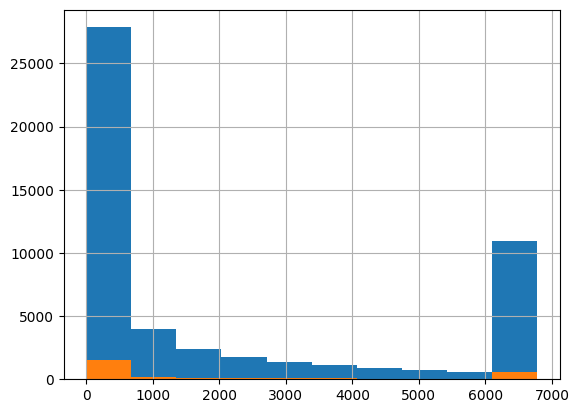

In [60]:
import copy
np.random.seed(seed = 0)
# MAKE SYNTHETIC Y
theta_x = np.random.uniform(size=len(x_cols_final))
theta_o = np.random.uniform(size=len(o_cols_final))

prev_mean = train.Y .median()
prev_std = train.Y .std()

prev_min = train.Y .min()
prev_max = train.Y .max()

X_train = train[x_cols_final]
O_train = train[o_cols_final]

cit_index = O_train.columns.get_loc("COLD_ISCH")
impact = theta_o[cit_index] 
theta_o[cit_index] = -impact
print("impact" , impact)
# 1. create Y_train
Y_train = np.exp((X_train @ theta_x + (O_train @ theta_o) * (O_train["DON_TY_C"] == 1)+ 0.5))
print(O_train["COLD_ISCH"], Y_train)

#Y_train = np.exp((X_train @ theta_x + (O_train @ theta_o) * (O_train["DON_TY_C"] == 1)+ 0.5))
#print(Y_train.hist())
#Y_train += 4*np.exp(-0.1 * O_train["COLD_ISCH"]) * (O_train["DON_TY_C"] == 1)
#print(Y_train.hist())
v = train.Y.median() / Y_train.median()
Y_train *= v
Y_train += np.random.normal(scale=0.1, size=Y_train.shape)
Y_train[Y_train < prev_min] = prev_min
Y_train[Y_train > prev_max] = prev_max

print(Y_train.hist())
print("TRAIN")
# 2. suffle X and O in test (no bias)
X_test = test[x_cols_final]
O_test = test[o_cols_final]

O_test = O_test.sample(frac=1)

# 3. create Y_test
Y_test = np.exp((X_test @ theta_x + (O_test @ theta_o) * (O_test["DON_TY_C"] == 1)+ 0.5))

Y_test *= v

Y_test[Y_test < prev_min] = prev_min
Y_test[Y_test > prev_max] = prev_max

print(Y_test.hist())
print("TEST")

train["Y_SYNTH"] = Y_train
test["Y_SYNTH"] = Y_test


In [71]:
v

13.155386576470548

6.6788032568959785

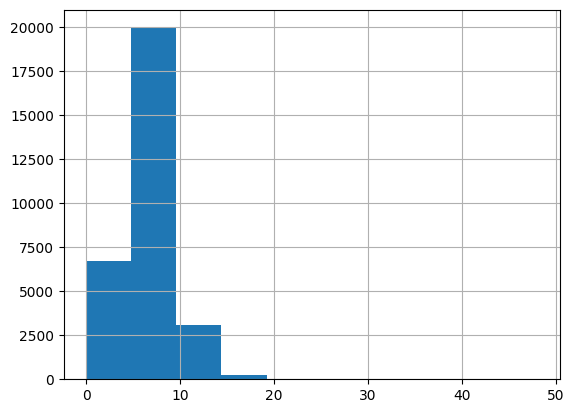

In [70]:
O.loc[O["DON_TY_C"] == 1]["COLD_ISCH"].hist()
O.loc[O["DON_TY_C"] == 1]["COLD_ISCH"].mean()

In [61]:
# SAVE
DATA.to_csv(f"{destination}/liver_processed.csv")

np.save(f"{destination}/liver_processed_conts.npy", conts)
np.save(f"{destination}/o_cols", o_cols_final)
np.save(f"{destination}/x_cols", x_cols_final)
np.save(f"{destination}/theta_x_Y", theta_x)
np.save(f"{destination}/theta_o_Y", theta_o)

joblib.dump(scaler, f"{destination}/scaler")

train.to_csv(f"{destination}/liver_processed_train.csv")
test.to_csv(f"{destination}/liver_processed_test.csv")

In [128]:
train.PSTATUS.value_counts()

PSTATUS
1.0    51662
Name: count, dtype: int64

In [598]:
train.RECEIVED_TX.value_counts()

RECEIVED_TX
1    29337
0    22325
Name: count, dtype: int64

In [84]:
train

,DAYSWAIT_CHRON,HGT_CM_CALC,INIT_AGE,INIT_ALBUMIN,INIT_BILIRUBIN,INIT_BMI_CALC,INIT_INR,INIT_SERUM_CREAT,INIT_SERUM_SODIUM,NUM_PREV_TX,...,HIST_CANCER_DON_N,HIST_CANCER_DON_U,HIST_CANCER_DON_Y,HIST_CIG_DON_0,HIST_CIG_DON_N,HIST_CIG_DON_U,HIST_CIG_DON_Y,NON_HRT_DON_0,NON_HRT_DON_N,NON_HRT_DON_Y
46170,-0.170413,-0.026930,0.127163,0.877002,-1.060630,-0.636450,-0.543042,-0.881318,0.004168,-0.261566,...,1,0,0,0,0,0,1,0,1,0
3578,1.323446,-4.928959,-0.182749,1.022653,-1.060630,0.183810,-0.747129,0.076855,-0.191877,-0.261566,...,0,0,0,1,0,0,0,1,0,0
16271,-0.387591,0.443710,0.592031,-0.579503,-0.115588,0.135933,0.300824,0.649502,-1.172104,-0.261566,...,1,0,0,0,0,0,1,0,1,0
19288,-0.097344,0.703118,0.127163,0.585701,-0.903795,-0.907203,-0.747129,-1.062740,0.984395,-0.261566,...,1,0,0,0,1,0,0,0,1,0
36118,-0.087195,-4.732971,0.824465,0.003099,-0.206221,0.961182,-0.178173,-0.222897,-0.976059,-0.261566,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2894,0.174636,-0.026930,-0.415183,-1.307756,0.920087,0.066020,-0.354086,-0.589765,0.788350,-0.261566,...,1,0,0,0,1,0,0,0,0,1
48732,-0.578382,0.147244,0.979421,-0.870804,2.354673,0.879688,2.622991,2.182823,-0.583968,-0.261566,...,1,0,0,0,1,0,0,0,1,0
19633,-0.087195,-5.098177,-0.260227,-1.016455,-0.656326,0.698356,-0.543042,-0.931142,-2.348377,-0.261566,...,0,0,0,1,0,0,0,1,0,0
23203,3.280077,-4.903534,0.359597,1.313954,-1.656886,-0.627884,-1.424600,-0.674096,1.964622,-0.261566,...,0,0,0,1,0,0,0,1,0,0


<Axes: >

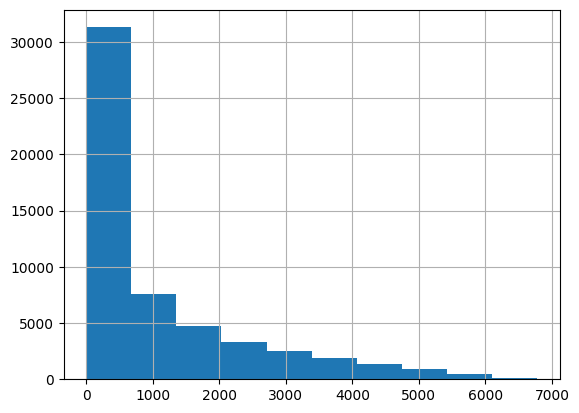

In [234]:
X.Y.hist()